# 03 — Modeling, Evaluation & SHAP
**Banking Churn Prediction**

Entrenamos y comparamos modelos, optimizamos el threshold para impacto de negocio, y analizamos interpretabilidad con SHAP.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              classification_report, confusion_matrix, f1_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline
from xgboost import XGBClassifier
import lightgbm as lgb
import joblib

from data_processing import load_raw, basic_cleaning, split_features_target
from features import ChurnFeatureEngineer, build_preprocessor
from predict import load_model, predict_proba, business_impact

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

df = load_raw('../data/raw/Customer-Churn-Records.csv')
df = basic_cleaning(df)
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Churn rate — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}')

Train: (8000, 13) | Test: (2000, 13)
Churn rate — train: 20.38% | test: 20.40%


## 1. Comparación de Modelos (sin SMOTE para comparación justa)

In [2]:
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                     random_state=42, n_jobs=-1, verbose=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, clf in MODELS.items():
    pipe = SkPipeline([
        ('engineer', ChurnFeatureEngineer()),
        ('preprocessor', build_preprocessor()),
        ('clf', clf),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f'{name:25s}: AUC = {scores.mean():.4f} ± {scores.std():.4f}')

print('\n→ XGBoost y LightGBM son candidatos finales.')

Logistic Regression      : AUC = 0.8436 ± 0.0046


Random Forest            : AUC = 0.8532 ± 0.0055


XGBoost                  : AUC = 0.8588 ± 0.0064


LightGBM                 : AUC = 0.8516 ± 0.0081

→ XGBoost y LightGBM son candidatos finales.


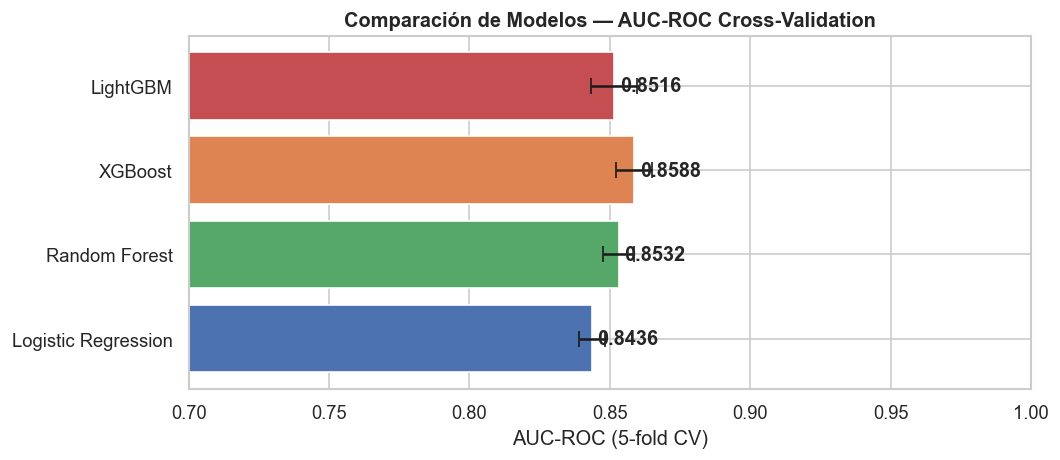

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
names = list(results.keys())
means = [results[n]['mean'] for n in names]
stds  = [results[n]['std']  for n in names]

bars = ax.barh(names, means, xerr=stds, color=['#4C72B0', '#55A868', '#DD8452', '#C44E52'],
               edgecolor='white', capsize=5)
ax.set_xlabel('AUC-ROC (5-fold CV)')
ax.set_title('Comparación de Modelos — AUC-ROC Cross-Validation', fontweight='bold')
ax.set_xlim(0.7, 1.0)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Curvas ROC y Precision-Recall

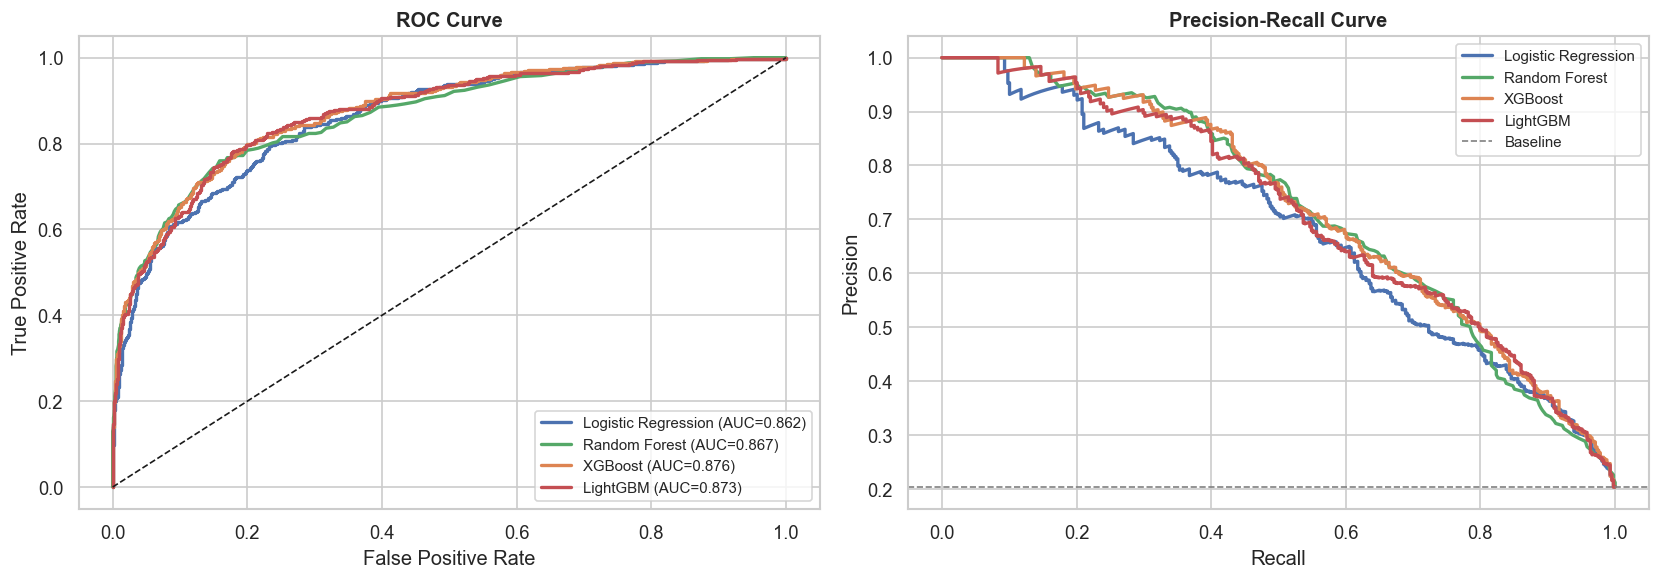

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

for (name, clf), color in zip(MODELS.items(), colors):
    pipe = SkPipeline([
        ('engineer', ChurnFeatureEngineer()),
        ('preprocessor', build_preprocessor()),
        ('clf', clf),
    ])
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

    p, r, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(r, p, color=color, lw=2, label=name)

axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].axhline(y_test.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. Modelo Final — XGBoost + SMOTE + Threshold Optimizado

In [5]:
artifact = load_model('../models/churn_model.joblib')
threshold = artifact['threshold']
pipeline = artifact['pipeline']
print(f'Threshold: {threshold}')
print(f'Metrics: {artifact["metrics"]}')

y_proba_test = predict_proba(artifact, X_test)
y_pred_test = (y_proba_test >= threshold).astype(int)

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred_test, target_names=['No Churn', 'Churn']))

Threshold: 0.554
Metrics: {'auc_roc': 0.8726, 'threshold': 0.554, 'precision': 0.7526, 'recall': 0.5294, 'f1': 0.6216, 'support': 408, 'accuracy': 0.8685}

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    No Churn       0.89      0.96      0.92      1592
       Churn       0.75      0.53      0.62       408

    accuracy                           0.87      2000
   macro avg       0.82      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000



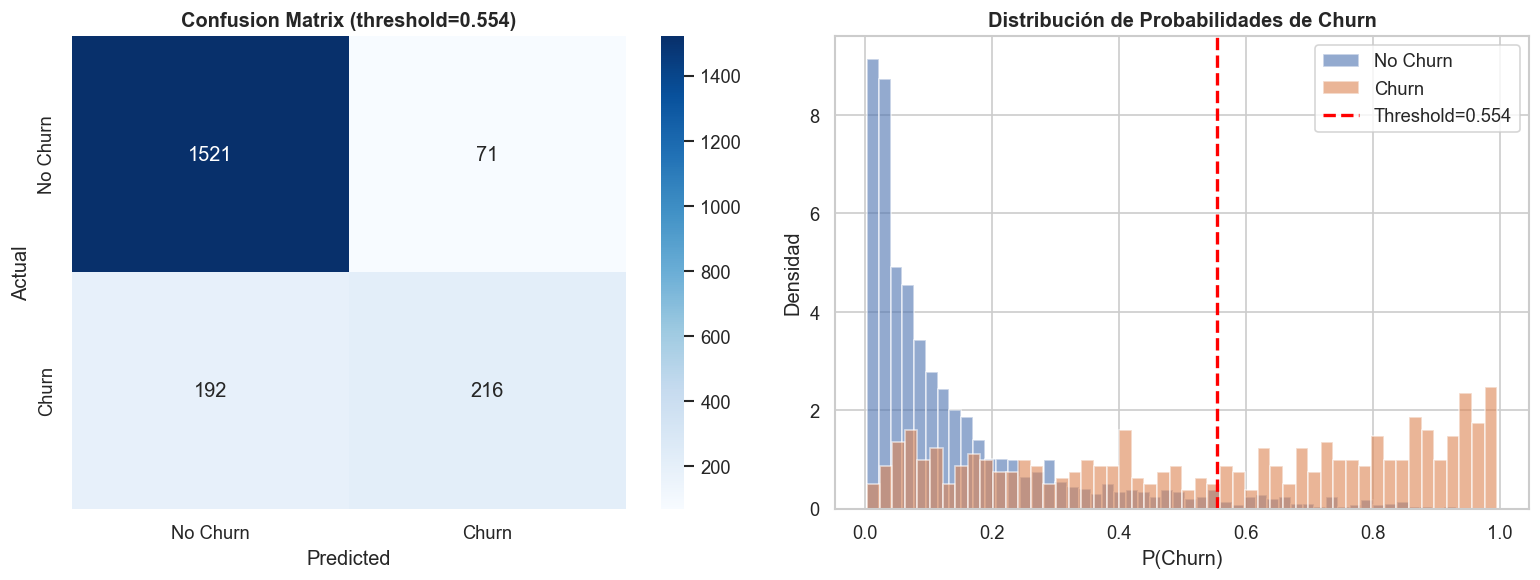

In [6]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'Confusion Matrix (threshold={threshold})', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Score distribution
axes[1].hist(y_proba_test[y_test == 0], bins=50, alpha=0.6,
             color='#4C72B0', label='No Churn', density=True)
axes[1].hist(y_proba_test[y_test == 1], bins=50, alpha=0.6,
             color='#DD8452', label='Churn', density=True)
axes[1].axvline(threshold, color='red', linestyle='--', lw=2, label=f'Threshold={threshold}')
axes[1].set_title('Distribución de Probabilidades de Churn', fontweight='bold')
axes[1].set_xlabel('P(Churn)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Threshold Analysis — Impacto de Negocio

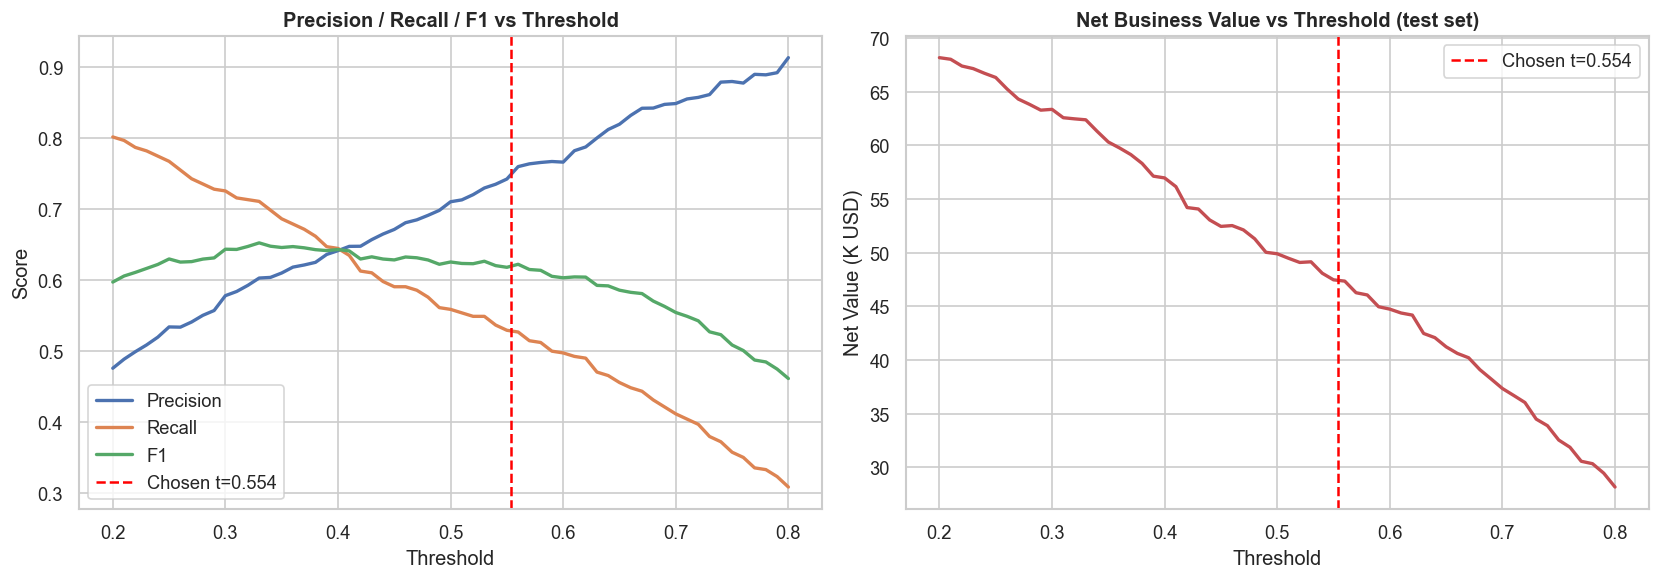

Threshold que maximiza valor de negocio: 0.20
Net value en ese threshold: $68,175 (sobre test set de 2000 clientes)


In [7]:
CLV = 800
CONTACT_COST = 15
RETENTION_RATE = 0.30

thresholds = np.arange(0.20, 0.80, 0.01)
precisions_t, recalls_t, f1s_t, net_values_t = [], [], [], []

for t in thresholds:
    y_pred = (y_proba_test >= t).astype(int)
    tp = ((y_pred == 1) & (y_test == 1)).sum()
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    fn = ((y_pred == 0) & (y_test == 1)).sum()

    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    flagged = tp + fp
    net = flagged * CLV * RETENTION_RATE * prec - flagged * CONTACT_COST

    precisions_t.append(prec)
    recalls_t.append(rec)
    f1s_t.append(f1)
    net_values_t.append(net)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions_t, label='Precision', color='#4C72B0', lw=2)
axes[0].plot(thresholds, recalls_t, label='Recall', color='#DD8452', lw=2)
axes[0].plot(thresholds, f1s_t, label='F1', color='#55A868', lw=2)
axes[0].axvline(threshold, color='red', linestyle='--', lw=1.5, label=f'Chosen t={threshold}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
axes[0].legend()

axes[1].plot(thresholds, [v/1000 for v in net_values_t], color='#C44E52', lw=2)
axes[1].axvline(threshold, color='red', linestyle='--', lw=1.5, label=f'Chosen t={threshold}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Net Value (K USD)')
axes[1].set_title('Net Business Value vs Threshold (test set)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

best_t_idx = np.argmax(net_values_t)
print(f'Threshold que maximiza valor de negocio: {thresholds[best_t_idx]:.2f}')
print(f'Net value en ese threshold: ${net_values_t[best_t_idx]:,.0f} (sobre test set de 2000 clientes)')

## 5. SHAP — Interpretabilidad Global

In [8]:
from sklearn.pipeline import Pipeline as SkPipeline

# Build transform pipeline (engineer + preprocessor, no SMOTE, no classifier)
steps_without_clf = [(name, step) for name, step in pipeline.steps
                     if name not in ('smote', 'classifier')]
transform_pipe = SkPipeline(steps_without_clf)

X_test_enc = transform_pipe.transform(X_test)
feature_names = list(pipeline.named_steps['preprocessor'].get_feature_names_out())

classifier = pipeline.named_steps['classifier']
explainer = shap.TreeExplainer(classifier)

# SHAP on a sample for speed
sample_idx = np.random.RandomState(42).choice(len(X_test_enc), 500, replace=False)
X_sample = X_test_enc[sample_idx]
shap_values = explainer.shap_values(X_sample)

print(f'SHAP computed on {len(X_sample)} test samples')
print(f'Feature count: {len(feature_names)}')

SHAP computed on 500 test samples
Feature count: 23


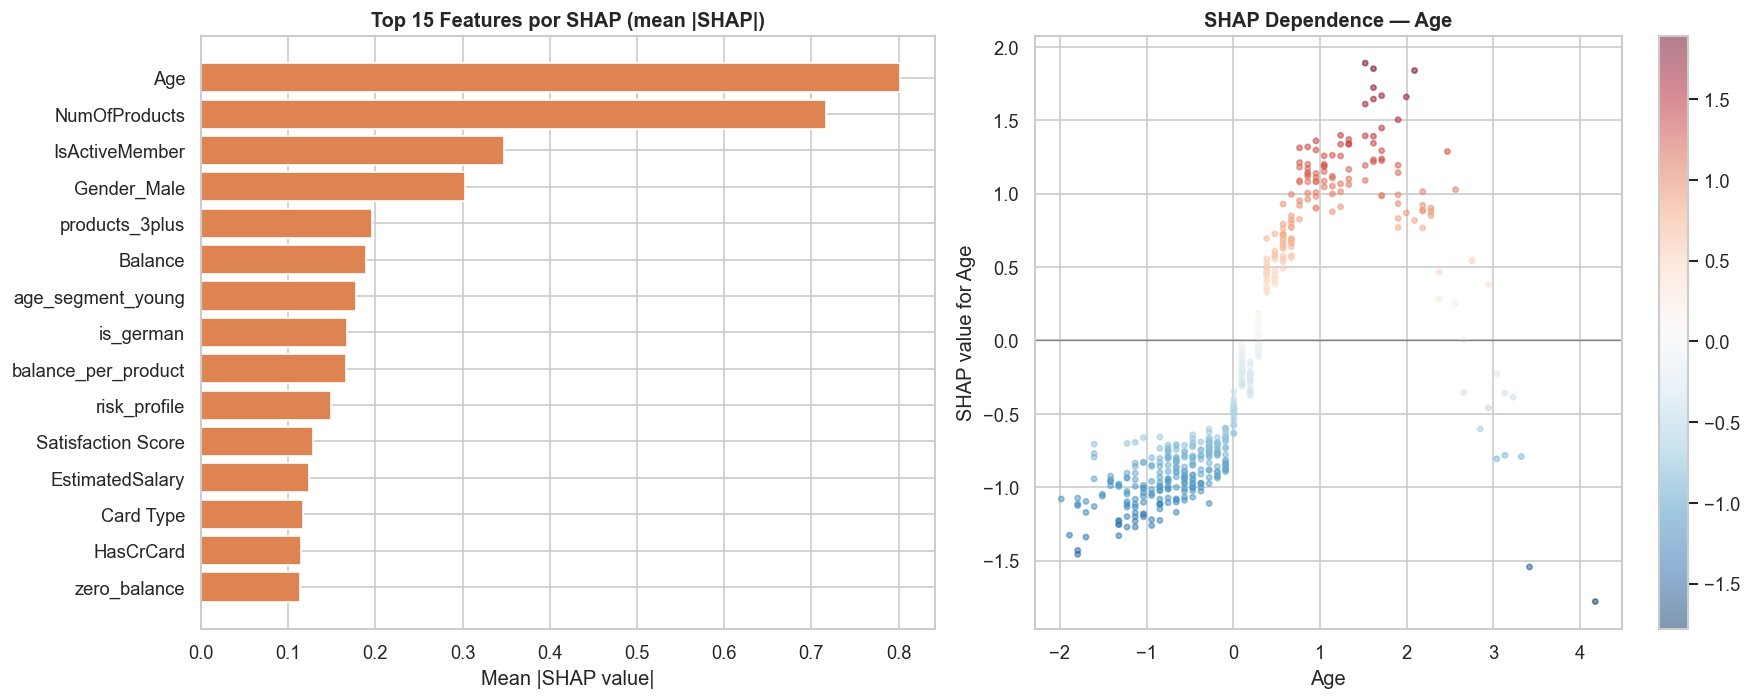

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Mean |SHAP| bar chart
mean_shap = np.abs(shap_values).mean(axis=0)
top_n = 15
top_idx = np.argsort(mean_shap)[-top_n:][::-1]

axes[0].barh(
    [feature_names[i] for i in top_idx[::-1]],
    mean_shap[top_idx[::-1]],
    color='#DD8452', edgecolor='white'
)
axes[0].set_title(f'Top {top_n} Features por SHAP (mean |SHAP|)', fontweight='bold')
axes[0].set_xlabel('Mean |SHAP value|')

# SHAP dependence for top feature
top_feature_idx = top_idx[0]
top_feature_name = feature_names[top_feature_idx]
scatter = axes[1].scatter(
    X_sample[:, top_feature_idx],
    shap_values[:, top_feature_idx],
    c=shap_values[:, top_feature_idx],
    cmap='RdBu_r', alpha=0.5, s=10
)
plt.colorbar(scatter, ax=axes[1])
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel(top_feature_name)
axes[1].set_ylabel(f'SHAP value for {top_feature_name}')
axes[1].set_title(f'SHAP Dependence — {top_feature_name}', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. SHAP — Waterfall para cliente individual

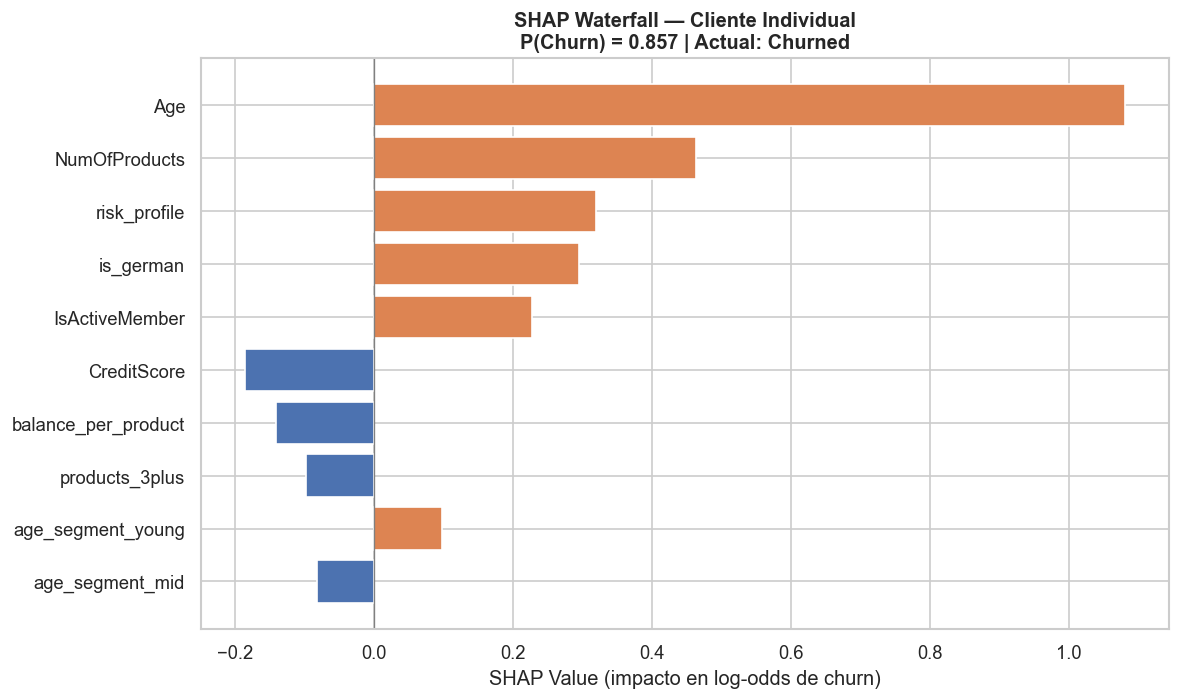

Base value (expected output): 0.009
Churn probability: 0.857


In [10]:
# Pick a high-risk churner from the test set
high_risk_idx = np.where((y_test.values == 1) & (y_proba_test > 0.80))[0]
if len(high_risk_idx) == 0:
    high_risk_idx = np.where(y_proba_test > threshold)[0]
sample_customer_idx = high_risk_idx[0]

shap_single = shap_values[sample_customer_idx] if sample_customer_idx < len(shap_values) else shap_values[0]
base_value = explainer.expected_value

top_k = 10
top_idx_single = np.argsort(np.abs(shap_single))[::-1][:top_k]
top_shap = shap_single[top_idx_single]
top_names = [feature_names[i] for i in top_idx_single]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in top_shap]
ax.barh(range(top_k), top_shap[::-1], color=colors[::-1], edgecolor='white')
ax.set_yticks(range(top_k))
ax.set_yticklabels(top_names[::-1])
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title(
    f'SHAP Waterfall — Cliente Individual\n'
    f'P(Churn) = {y_proba_test[sample_customer_idx]:.3f} | '
    f'Actual: {"Churned" if y_test.iloc[sample_customer_idx] == 1 else "Stayed"}',
    fontweight='bold'
)
ax.set_xlabel('SHAP Value (impacto en log-odds de churn)')
plt.tight_layout()
plt.show()

print(f'Base value (expected output): {base_value:.3f}')
print(f'Churn probability: {y_proba_test[sample_customer_idx]:.3f}')

## 7. Business Impact Summary — Test Set

In [11]:
impact = business_impact(artifact, X_test)

print('=== BUSINESS IMPACT ANALYSIS (Test Set: 2,000 clientes) ===')
print(f"Total clientes:          {impact['total_customers']:,}")
print(f"Predichos como churners: {impact['predicted_churners']:,} ({impact['churn_rate_predicted']:.1%})")
print(f"Revenue en riesgo:       ${impact['revenue_at_risk']:,.0f}")
print(f"Revenue recuperable:     ${impact['recoverable_revenue']:,.0f}")
print(f"Costo de intervención:   ${impact['intervention_cost']:,.0f}")
print(f"Valor neto estimado:     ${impact['net_value']:,.0f}")
print(f"\nSupuestos: CLV=${impact['assumptions']['clv']} | "
      f"Costo contacto=${impact['assumptions']['contact_cost']} | "
      f"Tasa retención={impact['assumptions']['retention_rate']:.0%}")

=== BUSINESS IMPACT ANALYSIS (Test Set: 2,000 clientes) ===
Total clientes:          2,000
Predichos como churners: 287 (14.3%)
Revenue en riesgo:       $229,600
Revenue recuperable:     $68,880
Costo de intervención:   $4,305
Valor neto estimado:     $64,575

Supuestos: CLV=$800 | Costo contacto=$15 | Tasa retención=30%
